(log-reg-notebook)=
# Modello di regressione logistica

In questo capitolo, approfondiremo la regressione logistica bivariata, un modello statistico che ci consente di analizzare le relazioni tra una variabile di esito binaria e una singola variabile indipendente. Esploreremo il processo di stima dei coefficienti del modello attraverso un approccio bayesiano, il quale ci offre stime a posteriori più informative e la possibilità di calcolare intervalli di credibilità per tali coefficienti. In aggiunta, forniremo un'interpretazione dei risultati ottenuti dalla regressione logistica. Mostreremo come i coefficienti influenzano la probabilità di successo della variabile binaria di esito, nonché come interpretare il loro segno e ampiezza. 

## Preparazione del Notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import bambi as bmb
from sklearn.metrics import confusion_matrix
from scipy.special import expit
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=Warning)

/var/folders/cl/wwjrsxdd5tz7y9jr82nd5hrw0000gn/T/ipykernel_21293/1891035395.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")
sns.set_theme(palette="colorblind")

## Regressione logistica

La regressione logistica rappresenta un metodo statistico fondamentale per l'analisi di variabili dipendenti che assumono due sole categorie, generalmente denominate "successo" (1) e "fallimento" (0). Questo approccio si rivela particolarmente utile in studi dove l'interesse è rivolto verso fenomeni dicotomici, come ad esempio l'indagine sulla tendenza di un individuo a dedicarsi alla meditazione giornaliera, con esiti categorizzati in 0 (non ha meditato) e 1 (ha meditato).

Quando si analizzano le risposte a domande quali "Quante volte hai meditato nell'ultimo periodo di sette giorni?", si entra nel dominio della regressione binomiale, che considera le proporzioni come variabile di risposta. Tale approccio, però, può comportare una semplificazione eccessiva dei dati, poiché informazioni dettagliate vengono omesse. Ad esempio, un valore proporzionale di 0.5 potrebbe derivare da diverse combinazioni di esiti, come 1 successo su 2 tentativi o 2 su 4, e questi dettagli specifici si perdono se ci si limita all'analisi delle sole proporzioni. Di conseguenza, è consigliabile, quando fattibile, analizzare i dati nella loro forma originaria, mantenendo l'intera sequenza di esiti 0 e 1, per preservare la ricchezza informativa e garantire un'analisi più accurata e dettagliata del fenomeno in esame.

Nell'ambito della statistica Bayesiana, la regressione logistica viene formulata considerando ciascun elemento, inclusi i coefficienti di regressione, come variabili casuali. L'obiettivo diventa quindi determinare la distribuzione a posteriori di questi coefficienti, utilizzando la formula di Bayes:

$$
p(\theta \mid y) = \frac{p(y \mid \theta) \cdot p(\theta)}{p(y)}.
$$

Sebbene il calcolo del denominatore possa risultare complesso, l'approccio Monte Carlo Markov Chain (MCMC) consente di superare questa difficoltà, concentrandosi principalmente sul numeratore. Ciò richiede la definizione di due componenti chiave: la distribuzione a priori $ p(\theta) $ e la funzione di verosimiglianza $ p(y \mid \theta) $. Generalmente, si predilige una distribuzione a priori poco informativa per minimizzare l'influenza di presupposti soggettivi e massimizzare quella dei dati osservati sulle stime posteriori.

La funzione di verosimiglianza nella regressione logistica si basa sul prodotto di $ n $ prove di Bernoulli, ognuna caratterizzata da:

$$
p_i^{y_i} (1 - p_i)^{1 - y_i},
$$

dove $ p_i = P(y_i = 1) $ rappresenta la probabilità di successo in un singolo evento Bernoulliano e $ y_i $ indica l'esito osservato (0 o 1).

Per esprimere $ p_i $, si utilizza comunemente la funzione logistica:

$$
p_i = \frac{1}{1 + e^{-\eta_i}},
$$

dove $ \eta_i $ deriva da una combinazione lineare di predittori $ X $ e coefficienti di regressione $ \theta $:

$$
\eta_i = \theta_0 + \theta_1 X_{i}.
$$

In questa espressione, $ \theta_0 $ è l'intercetta, mentre $ \theta_1 $ rappresenta il coefficiente associato al predittore $ X_i $. La funzione logit trasforma quindi $ \eta_i $ (il valore atteso della $y$), che varia nell'intervallo $ -\infty $ a $ \infty $, in una probabilità $ p_i $ compresa tra 0 e 1.

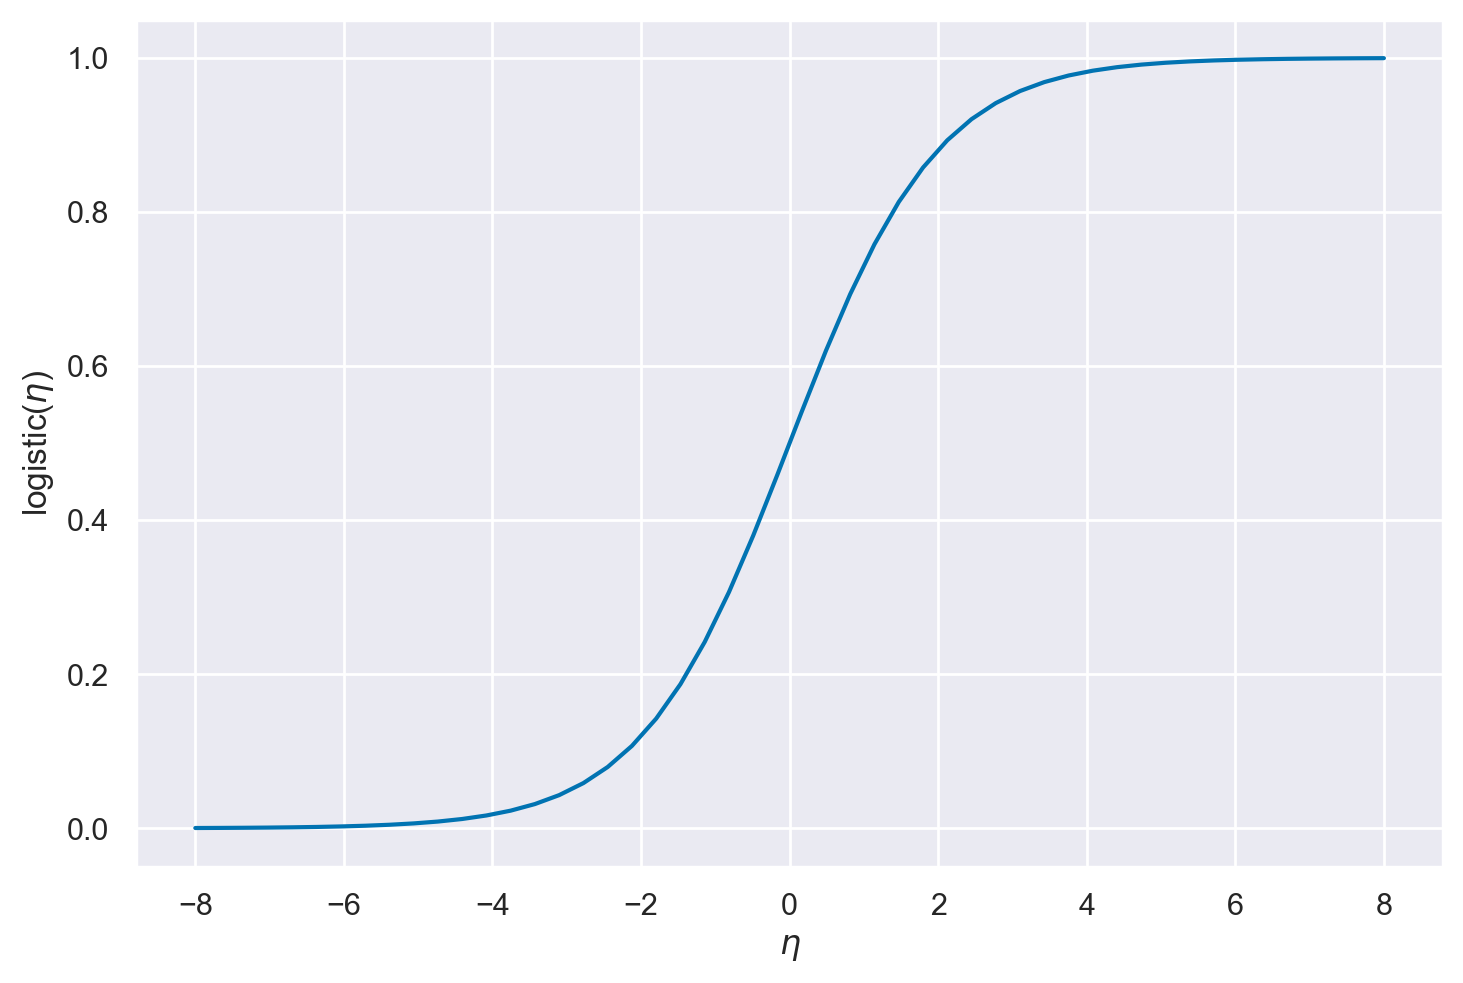

In [3]:
z = np.linspace(-8, 8)
plt.plot(z, 1 / (1 + np.exp(-z)))
plt.xlabel(r"$\eta$")  
plt.ylabel("logistic($\eta$)")  
plt.show()

In conclusione, la regressione logistica bayesiana estende il concetto di regressione lineare per modellare le probabilità condizionate di esiti Bernoulliani $ Y $, adoperando la funzione logistica come collegamento per trasformare relazioni lineari tra predittori ($ \eta_i = \theta_0 + \theta_1 X_{i} $) in probabilità nell'intervallo [0,1]. Questo metodo permette di passare dalla modellazione diretta della probabilità $ \pi $ alla modellazione di una funzione di tale probabilità attraverso una relazione lineare, impiegando la funzione logit come funzione di collegamento.

### Coefficienti del modello e logit

Proseguendo nell'esplorazione della regressione logistica, ci concentriamo sui coefficienti del modello e sulla loro relazione con i log-odds. I coefficienti, rappresentati come logaritmi degli odds ratio, offrono un meccanismo intuitivo per interpretare l'effetto dei predittori sulla probabilità dell'evento di interesse.

Consideriamo, ad esempio, un modello di regressione logistica con un unico predittore binario $X$, dove il coefficiente stimato per $X$ è $\beta_1 = 0.50$. In questo contesto, $\log(OR) = 0.50$ rappresenta il logaritmo dell'odds ratio associato a $X$. Per tradurre questo valore in termini comprensibili, ricorriamo all'esponenziazione:

$$
OR = e^{0.50} \approx 1.65.
$$

Questa trasformazione ci indica che, per il gruppo caratterizzato da $X = 1$, l'odds dell'evento di interesse è circa 1.65 volte maggiore rispetto al gruppo con $X = 0$. Un coefficiente negativo avrebbe suggerito un'associazione inversa, ovvero un'odds inferiore dell'evento per $X = 1$ rispetto a $X = 0$.

Approfondendo la connessione tra la funzione logistica e i log-odds, partiamo dalla definizione di $p_i$:

$$
p_i = \frac{1}{1 + e^{-\eta_i}}.
$$

Rielaborando l'espressione per isolare $e^{-\eta_i}$ in funzione di $p_i$, otteniamo:

$$
e^{-\eta_i} = \frac{1}{p_i} - 1 = \frac{1 - p_i}{p_i}.
$$

Invertendo entrambi i lati dell'equazione, giungiamo a:

$$
e^{\eta_i} = \frac{p_i}{1 - p_i}.
$$

Applicando il logaritmo naturale, deriviamo $\eta_i$ come:

$$
\eta_i = \ln\left(\frac{p_i}{1 - p_i}\right).
$$

Questa derivazione conferma che $\eta_i$, espresso come una combinazione lineare dei predittori ($\theta_0 + \theta_1 X_{i}$), corrisponde al logaritmo del rapporto delle probabilità, o log-odds. Questa relazione evidenzia il legame diretto tra la modellazione logistica e la struttura logaritmica degli odds, facilitando l'interpretazione dei coefficienti del modello in termini di effetto sui log-odds dell'evento analizzato.



## Un esempio concreto

Esaminiamo ora come eseguire la regressione logistica con PyMC. 

## American National Election Studies (ANES)

In questo tutorial, utilizzeremo un set di dati forniti dal sito di Bambi per illustrare il modello di regressione logistica. Questi dati provengono da uno studio pilota del 2016. L'intero studio comprendeva un campione di 1200 individui, ma per questo tutorial, è stato selezionato un sottoinsieme di 487 partecipanti che hanno risposto a una specifica domanda riguardante la loro intenzione di voto tra Hillary Clinton e Donald Trump.

Importiamo i dati.

In [4]:
data = bmb.load_data("ANES")
data.head()

,vote,age,party_id
0,clinton,56,democrat
1,trump,65,republican
2,clinton,80,democrat
3,trump,38,republican
4,trump,60,republican


La nostra variabile di esito è `vote`, che indica le risposte delle persone alla seguente domanda:

> If the 2016 presidential election were between Hillary Clinton for the Democrats and Donald Trump for the Republicans, would you vote for Hillary Clinton, Donald Trump, someone else, or probably not vote?

Esaminiamo la distribuzione di frequenze della variabile `vote`.

In [5]:
data["vote"].value_counts()

vote
clinton         215
trump           158
someone_else     48
Name: count, dtype: int64

Per semplificare l'analisi, qui considereremo solo le risposte `Clinton` e `Trump`. 

In [6]:
clinton_data = data.loc[data["vote"].isin(["clinton", "trump"]), :]
clinton_data.head()

,vote,age,party_id
0,clinton,56,democrat
1,trump,65,republican
2,clinton,80,democrat
3,trump,38,republican
4,trump,60,republican


## Specificare e adattare il modello in Bambi

Nel nostro esempio, miriamo a modellare la probabilità di voto per Clinton in funzione dell'età. L'obiettivo è quindi di utilizzare la regressione logistica per rappresentare $ \pi = P(Y = 1) $, cioè la probabilità di votare per Clinton, con l'età come variabile esplicativa.

La regressione logistica collega il logit di $ \pi $ a un predittore o a una combinazione lineare di predittori. Pertanto, l'equazione matematica del nostro modello sarà la seguente:

$$
\log\left(\frac{\pi}{1 - \pi}\right) = \beta_0 + \beta_1 X,
$$

dove $ X $ rappresenta l'età.

Per applicare l'approccio bayesiano, dobbiamo specificare una distribuzione a priori per i parametri e una funzione di verosimiglianza. Nella nostra analisi, useremo le distribuzioni a priori predefinite offerte da Bambi, e la funzione di verosimiglianza sarà il prodotto delle prove Bernoulliane, ovvero:

$$
\prod_{i=1}^{n}{p_i^{y_i}(1-p_i)^{1-y_i}},
$$

dove $ p_i = P(Y=1) $ e $ y_i = 1 $ se l'intenzione di voto è per Clinton, mentre $ y_i = 0 $ se è per Trump.

La specificazione del modello è resa intuitiva dalla sintassi richiesta da Bambi: basta formulare il modello seguendo la sintassi delle formule di Wilkinson {cite:p}`wilkinson1973symbolic` e fornire il corretto argomento per `family`. Vale la pena notare l'uso di una sintassi opzionale sul lato sinistro della formula: `vote[clinton]` indica a Bambi che intendiamo modellare la probabilità che `vote` sia uguale a `clinton`, piuttosto che a `trump`.

Sul lato destro della formula, utilizziamo il termine `age` per segnalare a Bambi la nostra intenzione di includere la variabile esplicativa `age` nel modello.

In [7]:
clinton_model = bmb.Model("vote['clinton'] ~ age", clinton_data, family="bernoulli")

Procediamo ora con il campionamento. L'argomento opzionale `idata_kwargs={"log_likelihood": True}` richiede il calcolo del logaritmo della verosimiglianza (log-likelihood) durante l'adattamento. Questo passaggio è rischiesto per potere utilizzare in seguito varie funzioni che valutano quanto bene il modello si adatta ai dati.

In [8]:
clinton_fitted = clinton_model.fit(
    method="nuts_numpyro", idata_kwargs={"log_likelihood": True}
)

Modeling the probability that vote==clinton


Compiling...


Compilation time = 0:00:07.862462


Sampling...


  0%|                                                                                  | 0/2000 [00:00<?, ?it/s]

...

Sampling time = 0:00:02.767292


Transforming variables...


Transformation time = 0:00:00.106926


Computing Log Likelihood...


Log Likelihood time = 0:00:00.285081


Possiamo stampare l'oggetto `clinton_model` per visualizzare informazioni sulla distribuzione della risposta, la funzione link e le distribuzioni a priori.

In [9]:
clinton_model

       Formula: vote['clinton'] ~ age
        Family: bernoulli
          Link: p = logit
  Observations: 373
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 7.586)
            age ~ Normal(mu: 0.0, sigma: 0.1454)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

Otteniamo una rappresentazione delle distribuzioni a priori usate da Bambi.

Sampling: [Intercept, age]


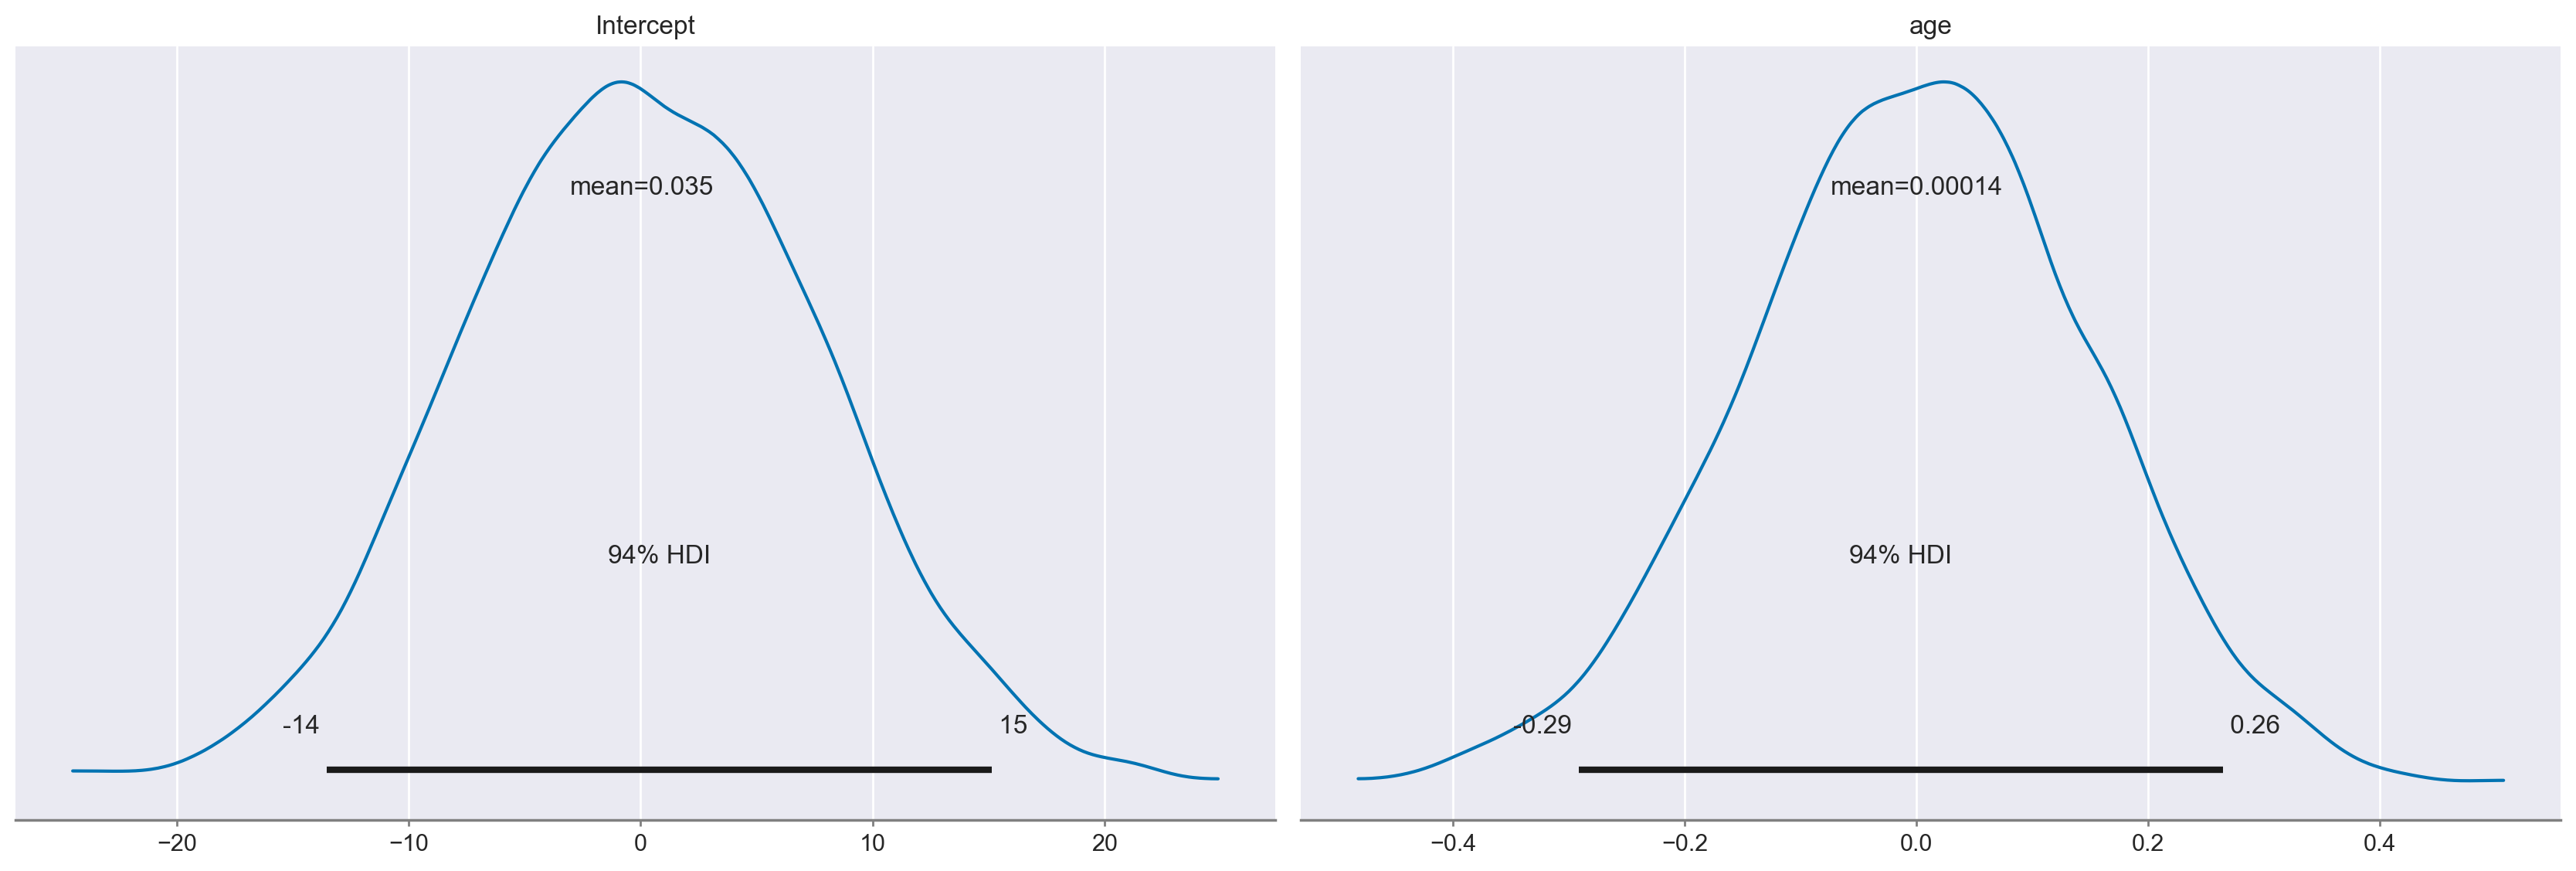

In [10]:
clinton_model.plot_priors()
plt.show()

## Valutazione del modello

Esaminiamo i trace plot delle distribuzioni a posteriori dei parametri.

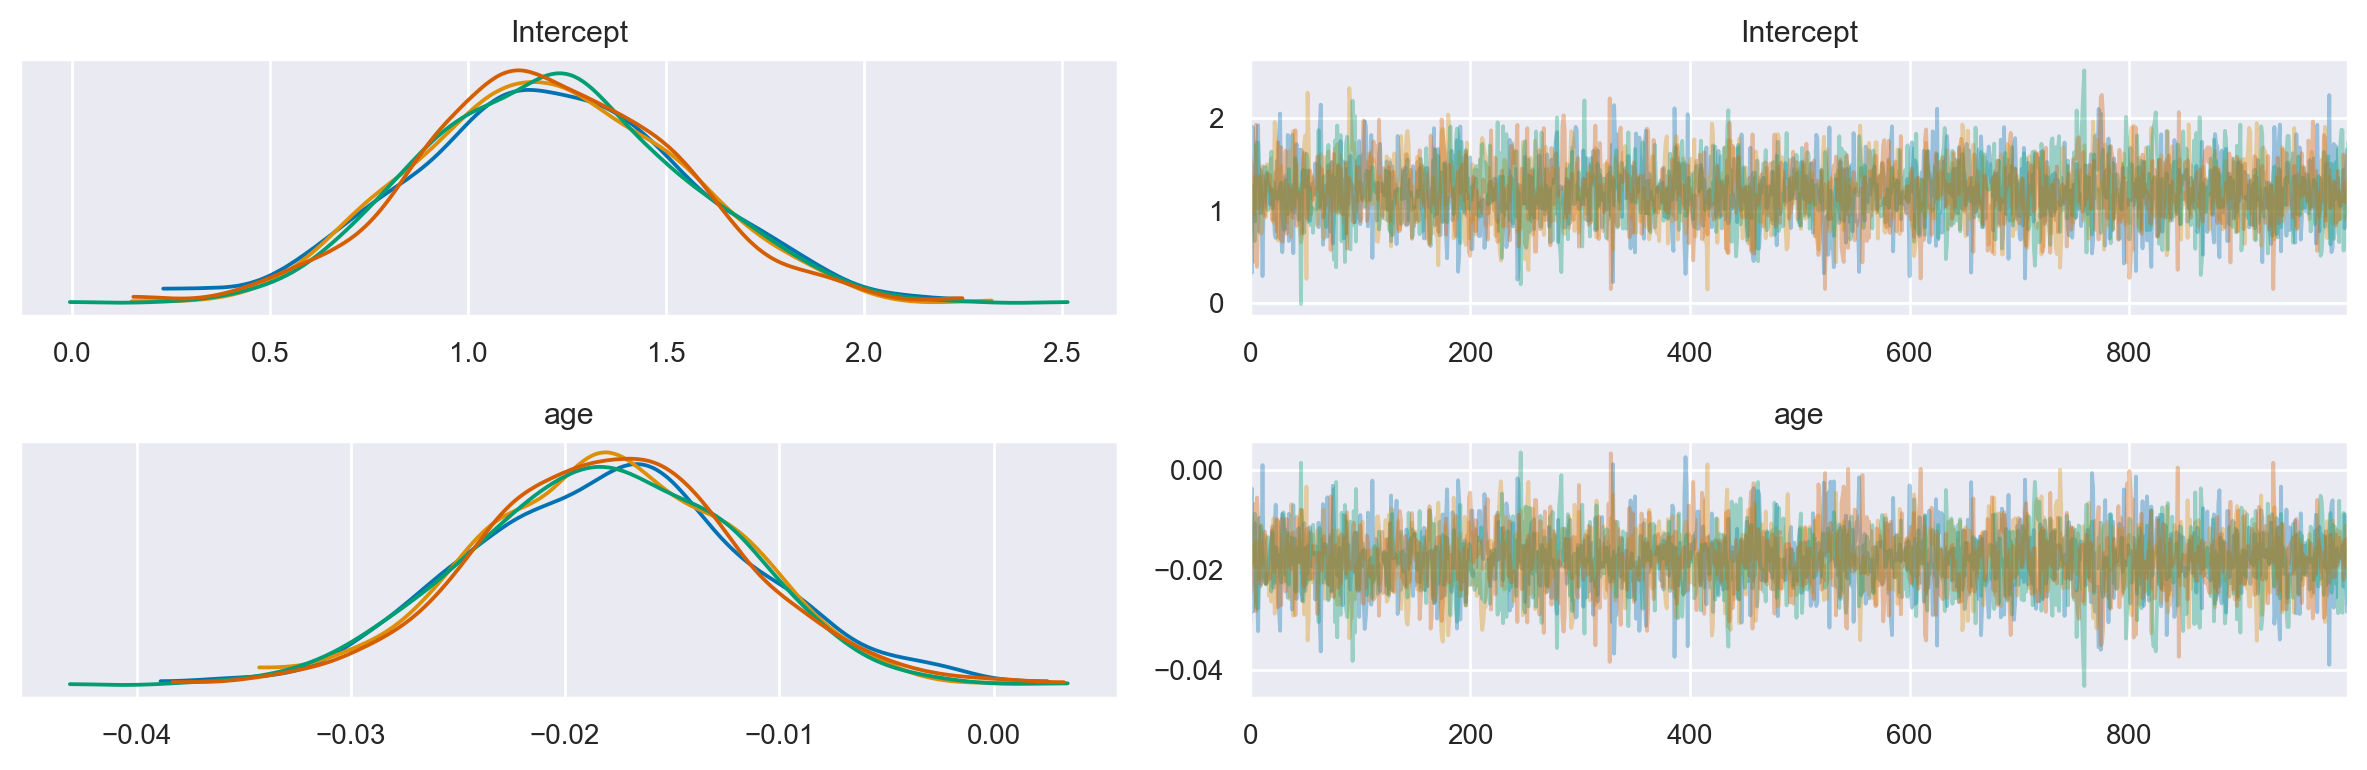

In [11]:
az.plot_trace(clinton_fitted, combined=False, compact=False)
plt.tight_layout()
plt.show()

### Posterior Predictive Check

Generiamo le previsioni posteriori dal modello di regressione logistica bivariata adattato ai dati di voto per Clinton. Il parametro `clinton_fitted` rappresenta l'output dell'adattamento del modello, che contiene le stime posteriori dei parametri del modello. Il parametro `kind="pps"` indica il tipo di previsione che vogliamo ottenere, nel caso specifico "pps" sta per "posterior predictive samples" (campioni predittivi posteriori). Questo significa che stiamo generando campioni casuali da una distribuzione predittiva basata sui parametri stimati e sulle distribuzioni a posteriori. In altre parole, stiamo simulando possibili risultati futuri o predizioni che potrebbero verificarsi dato il modello adattato ai dati.

In [12]:
posterior_predictive = clinton_model.predict(clinton_fitted, kind="pps")

Otteniamo il Posterior Preditive Check.

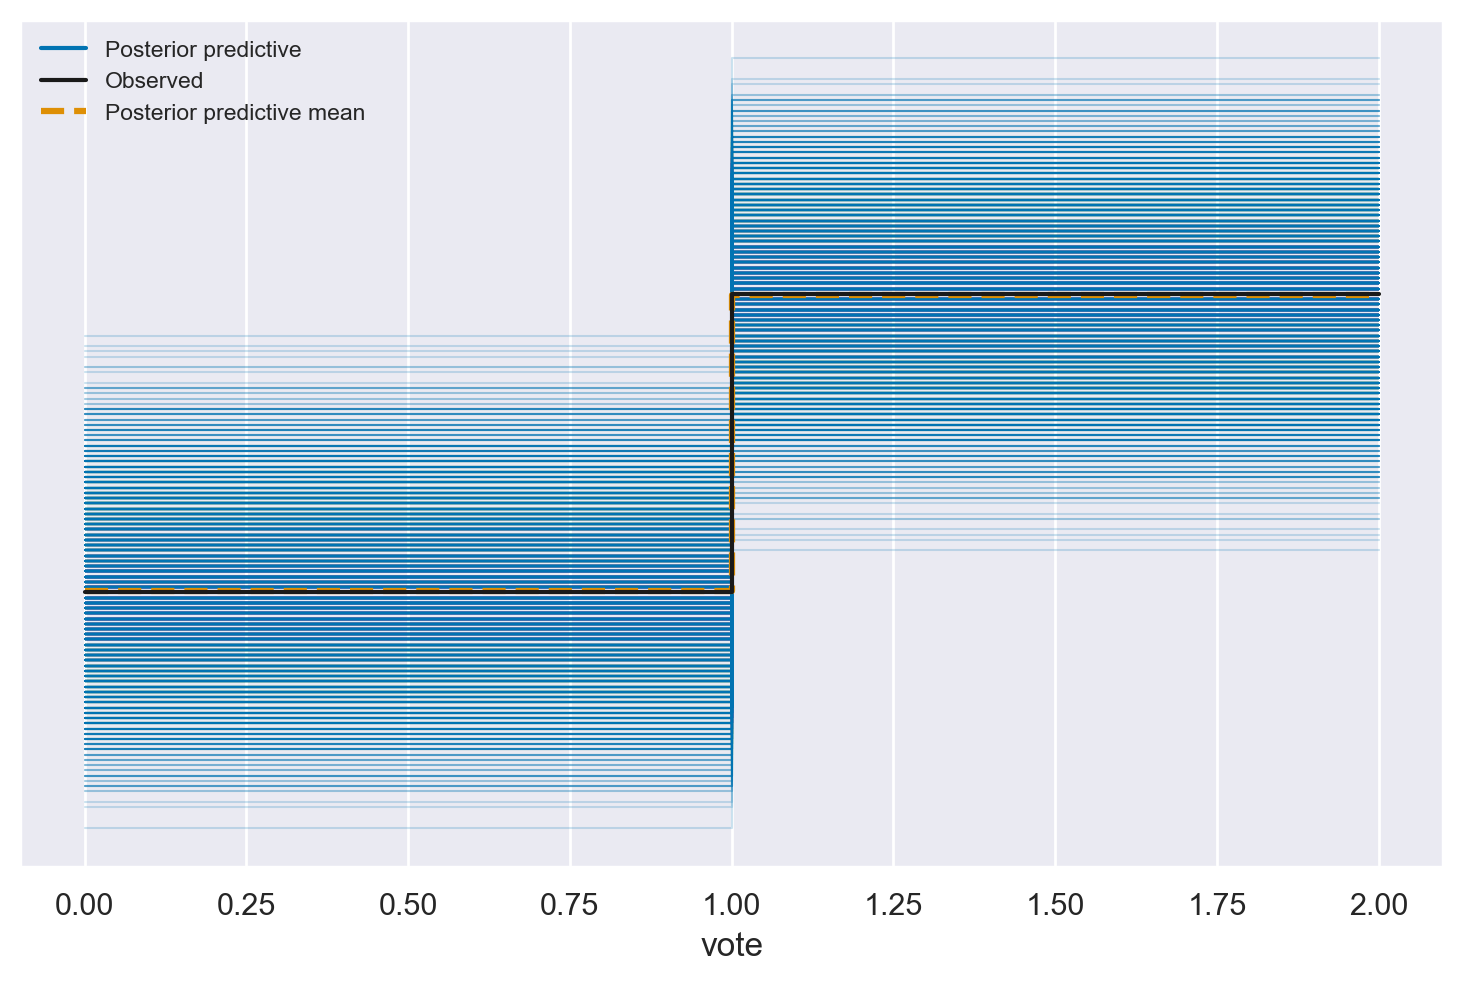

In [13]:
az.plot_ppc(clinton_fitted)
plt.show()

I possibili risultati futuri sono coerenti con i dati osservati, il che fornisce evidenze di un buon adattamento del modello.

## Parametro $\hat \kappa$

Possiamo utilizzare ArviZ per calcolare [LOO](https://arxiv.org/abs/1507.04544) e individuare le osservazioni che hanno un impatto significativo, basandoci sul valore stimato del parametro $\hat \kappa$. 

In [14]:
loo = az.loo(clinton_fitted, pointwise=True)

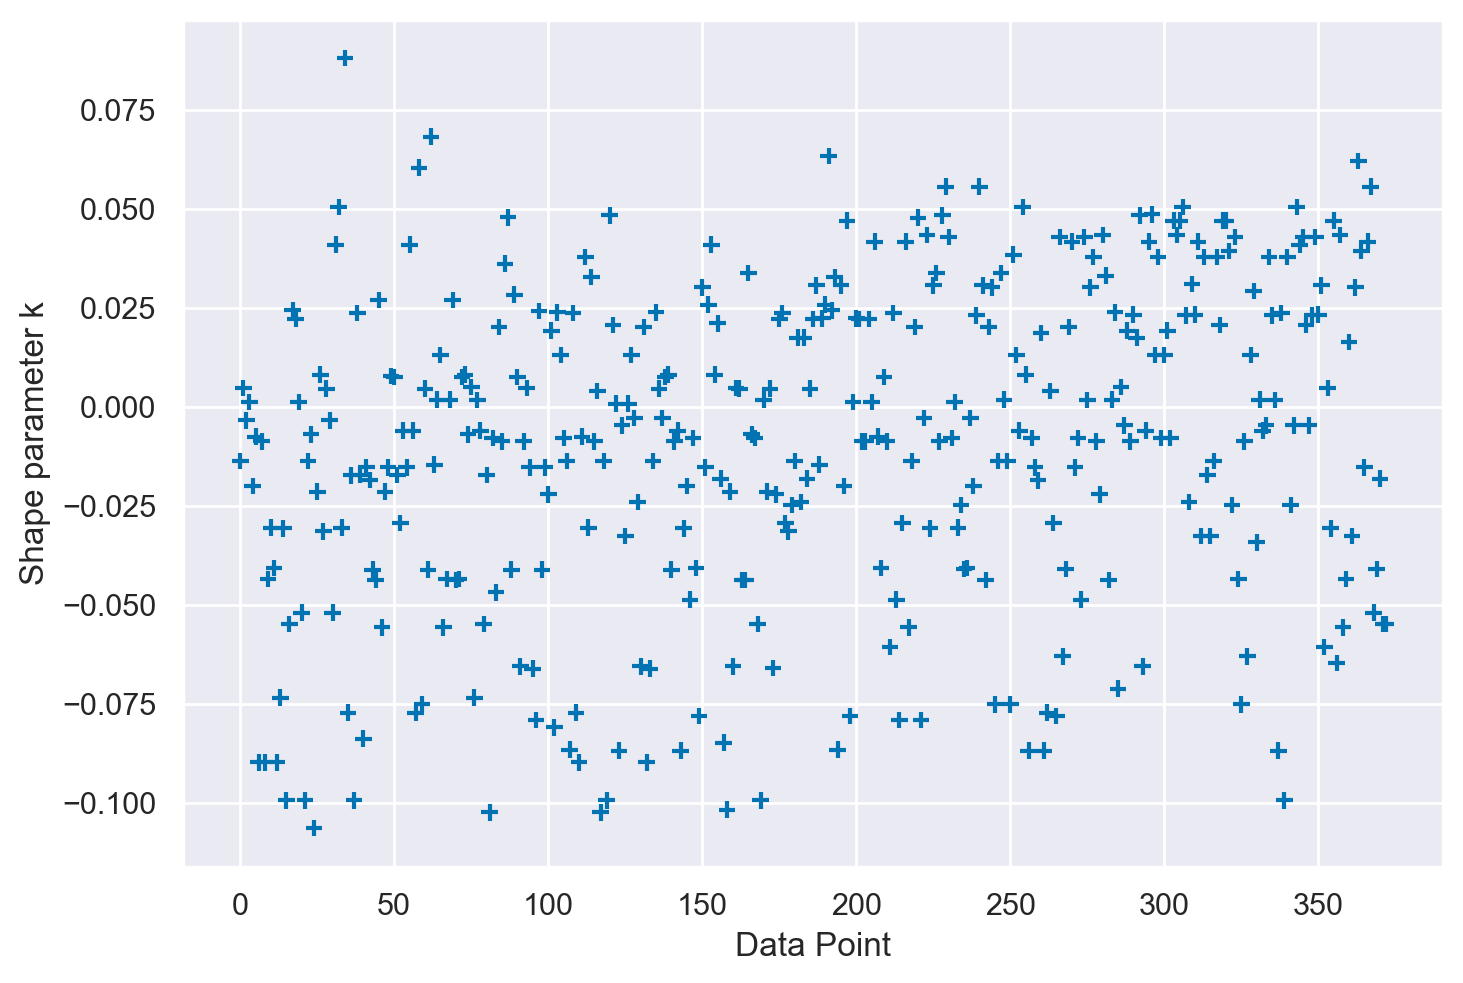

In [15]:
az.plot_khat(loo.pareto_k)
plt.show()

La presenza di valori di $|\hat \kappa| < 0.5$ nel grafico suggerisce un'elevata qualità dell'adattamento del modello, confermata dalla buona mescolanza delle catene MCMC. In questo contesto, non sono rilevabili problemi significativi di convergenza, né si osservano evidenze di punti dati particolarmente influenti. Questo è indicativo di un modello che si adatta efficacemente ai dati a disposizione.

## Inferenza

Esaminiamo una sintesi delle distribuzioni a posteriori dei parametri.

In [16]:
summary_df = az.summary(clinton_fitted)
print(summary_df)

                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
Intercept       1.204  0.333   0.574    1.821      0.006    0.004    3302.0   
age            -0.018  0.006  -0.030   -0.007      0.000    0.000    3547.0   
vote_mean[0]    0.548  0.027   0.496    0.599      0.000    0.000    3304.0   
vote_mean[1]    0.508  0.035   0.440    0.569      0.001    0.000    3562.0   
vote_mean[2]    0.441  0.052   0.348    0.542      0.001    0.001    3659.0   
...               ...    ...     ...      ...        ...      ...       ...   
vote_mean[368]  0.605  0.027   0.554    0.657      0.001    0.000    2965.0   
vote_mean[369]  0.592  0.026   0.546    0.645      0.000    0.000    2996.0   
vote_mean[370]  0.512  0.034   0.448    0.573      0.001    0.000    3546.0   
vote_mean[371]  0.622  0.030   0.564    0.675      0.001    0.000    2967.0   
vote_mean[372]  0.622  0.030   0.564    0.675      0.001    0.000    2967.0   

                ess_tail  r_hat  
Intercept        

### Interpretazione dei coefficienti nella regressione logistica

Sulla base delle distribuzioni a posteriori dei parametri, possiamo scrivere l'equazione del modello di regressione logistica nel modo seguente:

$$
\log{\left(\frac{\pi}{1 - \pi}\right)} = \beta_0 + \beta_1 \cdot \text{età}.
$$

### Interpretazione di $\beta_0$

Quando il predittore $X$ è pari a 0, $\beta_0$ rappresenta il logit dell'evento di interesse (voto per Clinton) e $e^{\beta_0}$ rappresenta gli odds di successo ($\pi / (1-\pi)$).

Nel caso presente, dunque, per un'età pari a 0, gli odds di successo ($\pi / (1-\pi)$) sono pari a

In [17]:
beta_0 = summary_df.loc['Intercept', 'mean']
print(beta_0)

1.204


In [18]:
np.exp(beta_0)

3.3334239868128988

e la probabilità di un voto per Clinton è

In [19]:
np.exp(beta_0) / (1 + np.exp(beta_0))

0.7692355968298709

Tuttavia, nel caso presente, l'intercetta non fornisce informazioni utili. Se avessimo trasformato i dati codificando l'età come scarti dalla media, le interpretazioni precedenti sarebbero riferite all'età media del campione, il che avrebbe più senso.

### Interpretazione di $\beta_1$

Quando $X$ aumenta di 1, da $x$ a $x+1$, $\beta_1$ rappresenta il cambiamento tipico nel logit, e $e^{\beta_1}$ rappresenta il cambiamento tipico moltiplicativo negli odds:

$$
\beta_1 = \log(\text{odds}_{x+1}) - \log(\text{odds}_x) \quad \text{e} \quad e^{\beta_1} = \frac{\text{odds}_{x+1}}{\text{odds}_x}.
$$

In altre parole, sulla scala lineare dei logit, il coefficiente $\beta_1$ rappresenta semplicemente la pendenza: per un cambiamento unitario dell'età, i logit del voto per Clinton diminuiscono di -0.018. 

Tuttavia, è più facile interpretare questo risultato sulla scala non lineare degli odds, dove questa variazione è moltiplicativa: per ogni anno di aumento dell'età, gli odds stimati dell'evento (votare per Clinton) vengono moltiplicati per $e^{\beta_1}$:

In [20]:
beta_1 = summary_df.loc['age', 'mean']
print(beta_1)

-0.018


In [21]:
np.exp(beta_1)

0.9821610323583008

Poiché la relazione di probabilità è una curva sigmoidale, non possiamo interpretare facilmente il coefficiente $\beta_1$ su questa scala. È invece preferibile rappresentare graficamente come varia la probabilità attesa di "successo" al variare dell'età. La rappresentazione di questa relazione, basata sulle stime a posteriori del modello, è fornita di seguito.

In [22]:
age = np.arange(18, 91)
new_data = pd.DataFrame({
    "age": np.tile(age, 3)
})
new_data

,age
0,18
1,19
2,20
3,21
4,22
...,...
214,86
215,87
216,88
217,89


In [23]:
clinton_model.predict(clinton_fitted, data=new_data)

In [24]:
vote_posterior = az.extract(clinton_fitted, num_samples=200)["vote_mean"]
vote_posterior.shape

(219, 200)

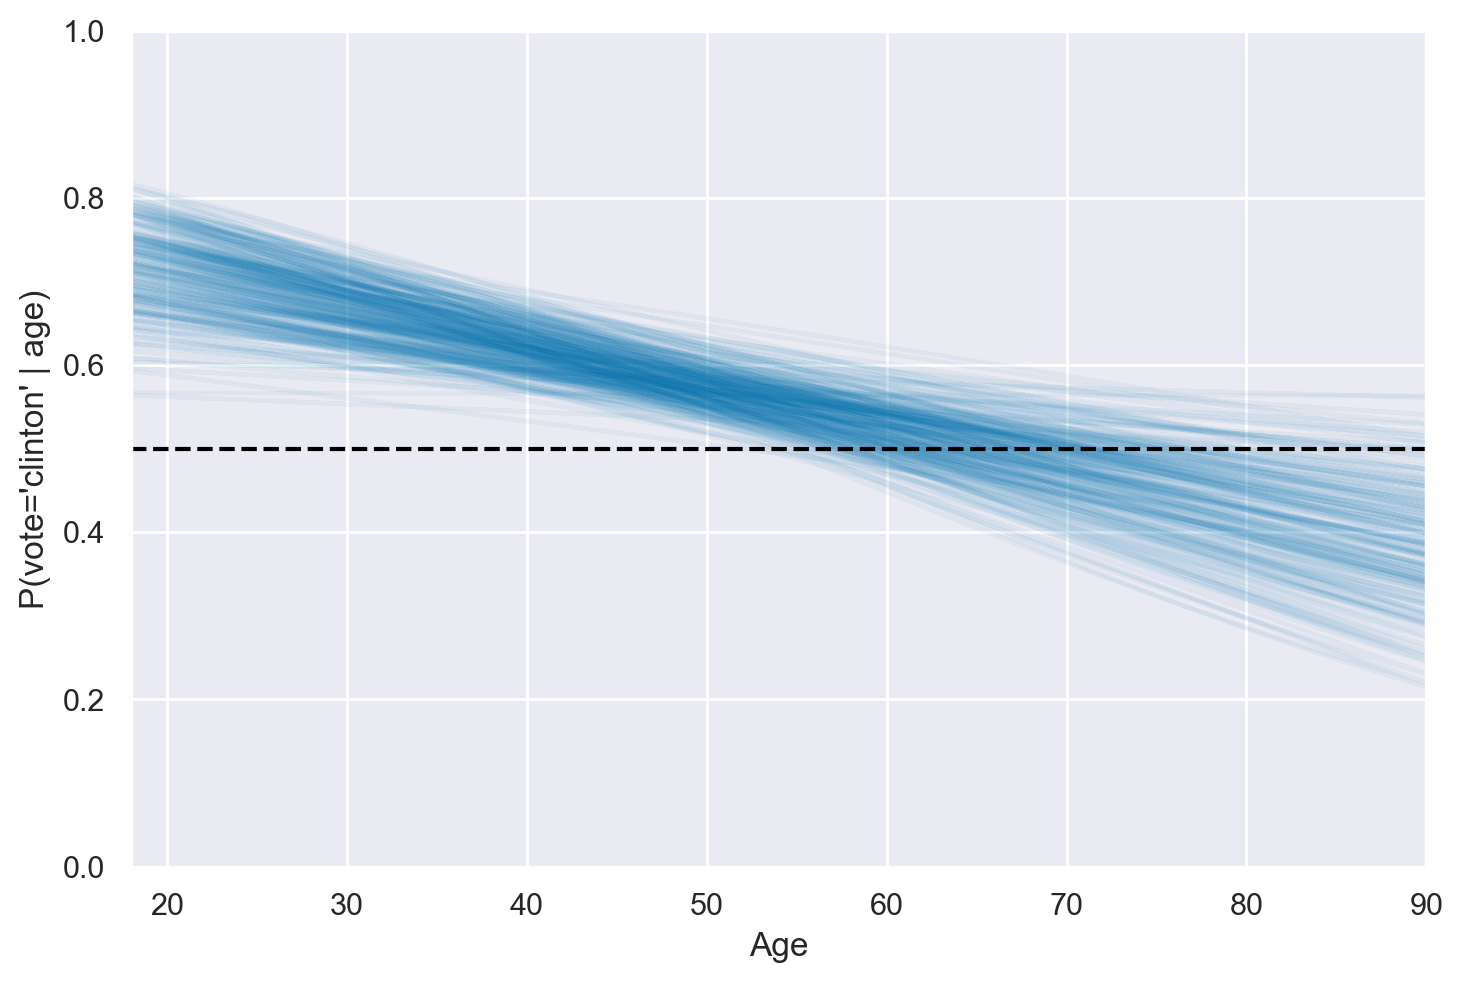

In [25]:
plt.plot(new_data.age, vote_posterior, alpha=0.05, color = "C0")

# Adding a dashed horizontal line at y=0.5 (50% probability)
plt.axhline(y=0.5, color="black", linestyle="dashed")

plt.ylabel("P(vote='clinton' | age)")
plt.xlabel("Age")
plt.ylim(0, 1)
plt.xlim(18, 90);

È possibile interpretare il grafico precedente nel seguente modo: fino all'età di circa 50 anni, la propensione al voto per Clinton supera quella per Trump. Proseguendo oltre i 50 anni, questa tendenza tende ad invertirsi. La presenza di più curve nel grafico indica l'incertezza a posteriori delle previsioni effettuate dal modello.

Per chiarire i risultati del modello di regressione logistica possiamo mostrare le predizioni del modello in due formati. Nel primo grafico, mostriamo i logit predetti come funzione lineare dell'età.

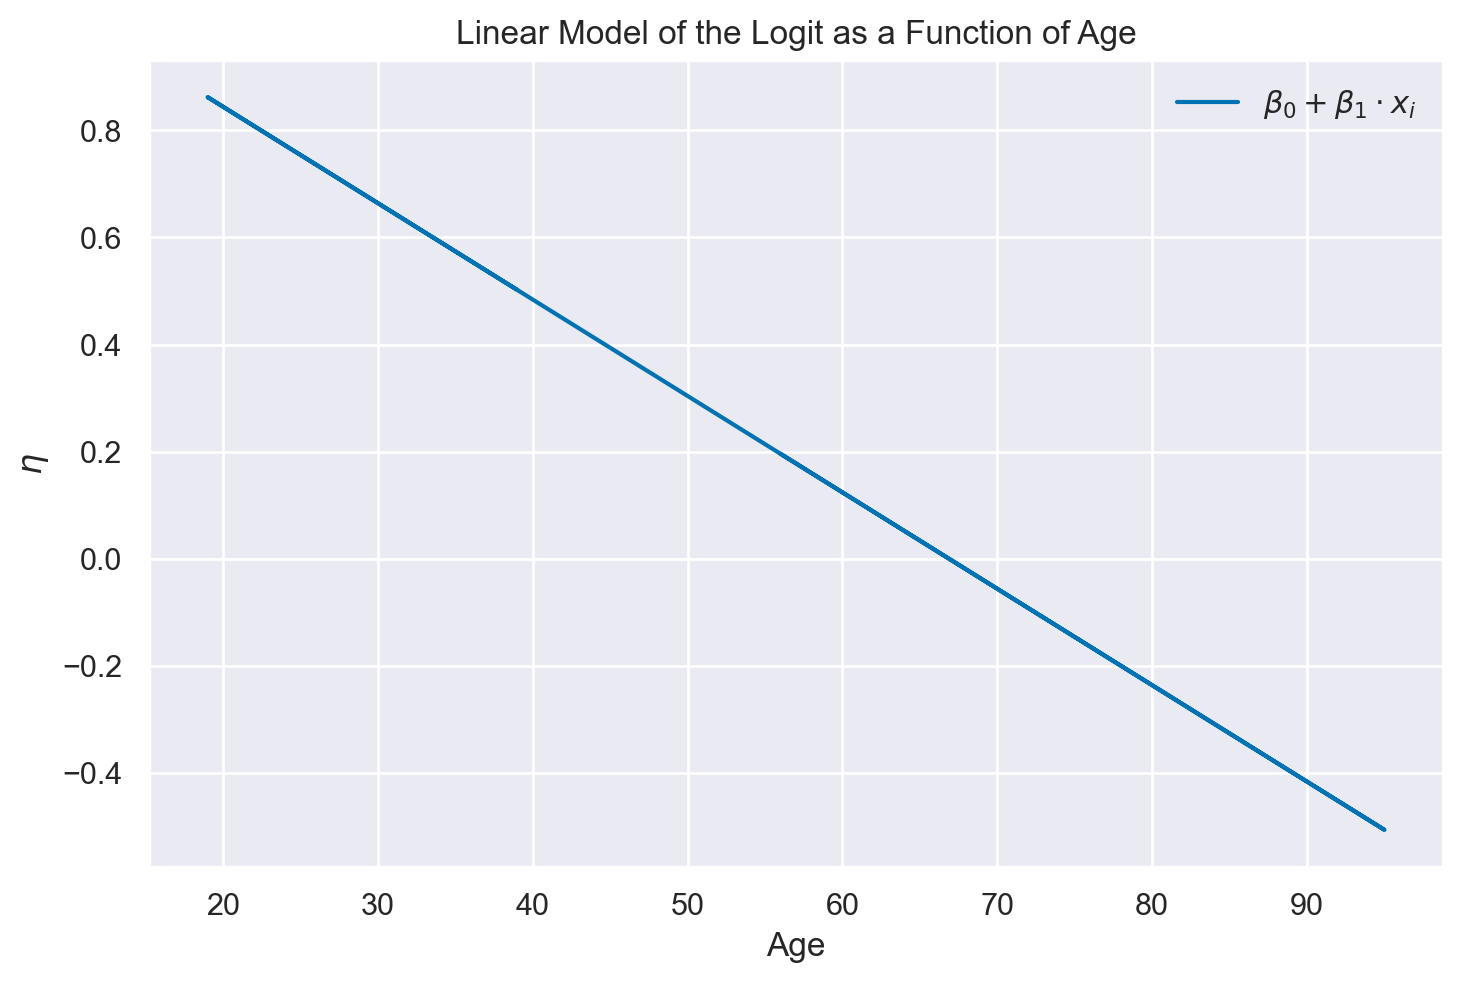

In [26]:
eta = beta_0 + beta_1 * clinton_data["age"]

plt.figure()
plt.plot(clinton_data["age"], eta, label=r"$\beta_0 + \beta_1 \cdot x_i$")
plt.xlabel("Age")  # Label for the x-axis
plt.ylabel(r"$\eta$")  # Label for the y-axis
plt.title("Linear Model of the Logit as a Function of Age")  # Title for the plot
plt.legend()
plt.show()

Nel secondo grafico mostriamo la probabilità di votare per Clinton come funzione non lineare dell'età.

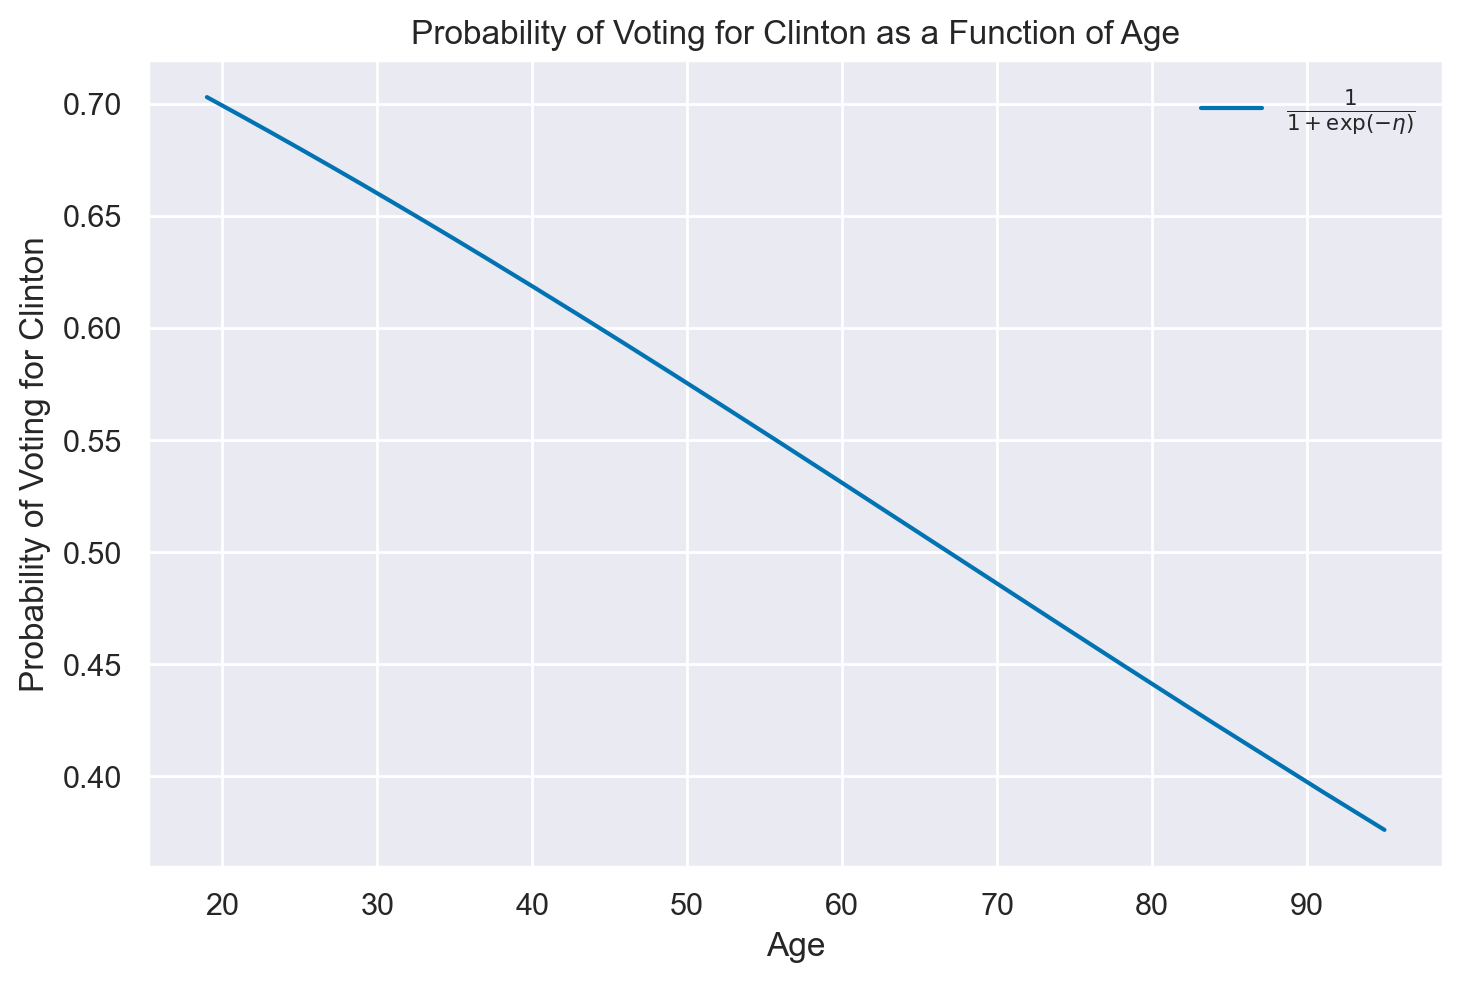

In [27]:
# Sort the age data first
sorted_age = np.sort(clinton_data["age"])

# Calculate eta using the sorted ages
eta_sorted = beta_0 + beta_1 * sorted_age

# Compute the sigmoid function
p_true_sorted = 1 / (1 + np.exp(-eta_sorted))

# Now, plot the sigmoid curve
plt.figure()
plt.plot(sorted_age, p_true_sorted, label=r"$\frac{1}{1 + \exp(-\eta)}$")
plt.xlabel("Age")
plt.ylabel(r"Probability of Voting for Clinton")  
plt.title("Probability of Voting for Clinton as a Function of Age")
plt.legend()
plt.show()

## Accuratezza delle classificazioni a posteriori

Esaminiamo ora la precisione delle nostre classificazioni posteriori. Nell'ambito della regressione, quando affrontiamo una variabile quantitativa  $Y$, abbiamo risposto a questa domanda analizzando la tipica differenza tra $Y$ e le sue previsioni posteriori. Tuttavia, nel contesto della classificazione con una variabile $Y$ categorica, le nostre classificazioni posteriori binarie di $Y$ possono essere corrette oppure errate. Pertanto, possiamo calcolare un indicatore globale di precisione.

Per procedere con il calcolo, il primo passo è determinare la probabilità a posteriori $P(Y = 1 | X)$, ovvero la probabilità che ciascuna osservazione rappresenti un voto per Clinton, per ogni singola osservazione.

Calcoliamo le probabilità predette dai coefficienti a posteriori del modello:

In [28]:
clinton_model.predict(clinton_fitted)

Le probabilità a posteriori possono essere estratte dall'oggetto `clinton_model` nel modo seguente.

In [29]:
print(clinton_fitted.posterior["vote_mean"])

<xarray.DataArray 'vote_mean' (chain: 4, draw: 1000, vote_obs: 373)>
array([[[0.56792954, 0.50042923, 0.38909863, ..., 0.50797555,
         0.68710172, 0.68710172],
        [0.529945  , 0.52181615, 0.50824447, ..., 0.52272   ,
         0.5452528 , 0.5452528 ],
        [0.5787459 , 0.51566729, 0.41042559, ..., 0.52273833,
         0.68979821, 0.68979821],
        ...,
        [0.54864025, 0.50165814, 0.42369815, ..., 0.50689509,
         0.63444182, 0.63444182],
        [0.51812625, 0.45438027, 0.3523188 , ..., 0.46142775,
         0.63533989, 0.63533989],
        [0.55254208, 0.51806397, 0.46038018, ..., 0.52190946,
         0.61606044, 0.61606044]],

       [[0.52388249, 0.475692  , 0.39679731, ..., 0.48104057,
         0.61301201, 0.61301201],
        [0.53471804, 0.4954027 , 0.4302415 , ..., 0.49977718,
         0.60744119, 0.60744119],
        [0.57201095, 0.53003309, 0.45941571, ..., 0.53472948,
         0.6481147 , 0.6481147 ],
...
        [0.52094552, 0.47708804, 0.40509405, ...

Otteniamo così un array multidimensionale di dimensioni avente le seguenti dimensioni: chain: 4, draw: 1000, vote_obs: 373. Vogliamo la media a posteriori per ciascuna osservazione, ovvero vogliamo ridurre l'array precedente ad un vettore di 373 elementi. A questo fine possiamo procedere come indicato di seguito.

In [30]:
probs_array = clinton_fitted.posterior["vote_mean"]
average_posterior_values = probs_array.mean(dim=("chain", "draw"))
clinton_data["probs"] = average_posterior_values.values
clinton_data.head()

,vote,age,party_id,probs
0,clinton,56,democrat,0.548176
1,trump,65,republican,0.507864
2,clinton,80,democrat,0.441214
3,trump,38,republican,0.626277
4,trump,60,republican,0.530294


Creaiamo la variabile `predicted` che assume il valore 1 se la probabilità di un'osservazione è maggiore di 0.5 e 0 altrimenti.

In [31]:
clinton_data["predicted"] = (clinton_data["probs"] > 0.5).astype(int);

Classifichiamo le osservazioni ricodificando il voto "clinton" con 1 e 0 altrimenti.

In [32]:
clinton_data["actual"] = (clinton_data["vote"] == "clinton").astype(int)

Creiamo una matrice di confusione.

In [33]:
confusion = confusion_matrix(clinton_data["actual"], clinton_data["predicted"])
print(confusion)

[[ 33 125]
 [ 31 184]]


### Sensibilità, specificità e accuratezza complessiva del modello

Consideriamo $ Y $ come un insieme di $ n $ etichette binarie vere per i dati osservati e $ \hat{Y} $ come il set di etichette previste dal modello di classificazione. Possiamo utilizzare una matrice di confusione per riassumere la performance del modello confrontando le etichette vere con quelle predette. In questa matrice, la somma $ a + b + c + d $ è uguale al numero totale $ n $ di osservazioni.

- $ a $: Veri Negativi (TN) - Entrambe le etichette, reale e prevista, sono 0.
- $ b $: Falsi Positivi (FP) - L'etichetta reale è 0, mentre l'etichetta prevista è 1.
- $ c $: Falsi Negativi (FN) - L'etichetta reale è 1, mentre l'etichetta prevista è 0.
- $ d $: Veri Positivi (TP) - Entrambe le etichette, reale e prevista, sono 1.

|           | $ \hat{Y} = 0 $  | $ \hat{Y} = 1 $  |
|-----------|--------------------|--------------------|
| $ Y = 0 $| $ a $ (TN)       | $ b $ (FP)       |
| $ Y = 1 $| $ c $ (FN)       | $ d $ (TP)       |

L'**accuratezza complessiva** fornisce una misura della proporzione di etichette vere che il modello è riuscito a classificare correttamente:

$$
\text{accuratezza complessiva} = \frac{a + d}{a + b + c + d}
$$

**Sensibilità** e **specificità** sono altre due metriche importanti:

- La **sensibilità** (o tasso di veri positivi) rappresenta la proporzione di osservazioni positive $ Y = 1 $ che sono state correttamente identificate dal modello:

$$
\text{sensibilità} = \frac{d}{c + d}
$$

- La **specificità** (o tasso di veri negativi) rappresenta la proporzione di osservazioni negative $ Y = 0 $ che sono state correttamente identificate dal modello:

$$
\text{specificità} = \frac{a}{a + b}
$$

Queste metriche forniscono una visione completa delle performance del modello di classificazione.

Per i dati presenti abbiamo un'accuratezza complessiva di

In [34]:
(33 + 184) / (33 + 125 + 31 + 184)

0.5817694369973191

Abbiamo una sensibilità di

In [35]:
184/ (31+184)

0.8558139534883721

e una specificità di

In [36]:
33 / (33+125)

0.2088607594936709

I risultati indicano che il modello ha una capacità predittiva molto limitata, soprattutto se consideriamo la sua specificità. È evidente che è stato troppo ambizioso tentare di predire le intenzioni di voto basandosi unicamente sull'età. Questo tutorial rappresenta una versione semplificata dell'esempio discusso nel sito di Bambi, dove, oltre all'età, viene utilizzata anche l'appartenenza a un partito politico come predittore. In quel contesto, è chiaro che l'intenzione di voto può essere prevista con una precisione maggiore. Nell'esempio attuale, a fini didattici, abbiamo volutamente semplificato il modello per avere un unico predittore.

## Commenti e considerazioni finali

In questo capitolo, abbiamo esplorato il modello di regressione logistica, una tecnica statistica utilizzata per analizzare le relazioni tra variabili binarie e variabili indipendenti, sia continue che categoriche. Abbiamo spiegato come il modello di regressione logistica impieghi il logit delle probabilità per modellare il legame tra le variabili di risultato e i predittori. La funzione logit trasforma l'intervallo di probabilità da 0 a 1 in un intervallo da meno infinito a più infinito, rendendo possibile l'utilizzo di un modello di regressione lineare nel caso di variabili dipendenti dicotomiche.

In aggiunta, abbiamo illustrato come interpretare i coefficienti nel contesto del modello di regressione logistica. Quando il modello coinvolge una singola variabile indipendente, la rappresentazione grafica delle probabilità attese si rivela uno strumento di grande valore per ottenere una comprensione più accurata dei risultati.

Infine, abbiamo introdotto l'approccio bayesiano per ottenere stime a posteriori dei parametri. Questo approccio ci permette di ottenere una visione più completa delle incertezze legate alle stime dei coefficienti. Attraverso l'aggiornamento bayesiano, siamo in grado di calcolare intervalli di credibilità in base al grado di certezza soggettiva desiderato, offrendo così un ulteriore livello di informazione e interpretazione all'analisi.

In [37]:
%load_ext watermark
%watermark -n -u -v -iv -w -m -p jax

Last updated: Sat Feb 17 2024

Python implementation: CPython
Python version       : 3.11.7
IPython version      : 8.21.0

jax: 0.4.23

Compiler    : Clang 16.0.6 
OS          : Darwin
Release     : 23.3.0
Machine     : x86_64
Processor   : i386
CPU cores   : 8
Architecture: 64bit

numpy     : 1.26.4
matplotlib: 3.8.2
bambi     : 0.13.0
pandas    : 2.2.0
seaborn   : 0.13.2
arviz     : 0.17.0

Watermark: 2.4.3

